<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/Random_Forest_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Model Training and Evaluation

The model is trained using the preprocessed and feature-selected CSE-CIC-IDS2018 dataset. Performance is evaluated using accuracy, precision, recall, F1-score and confusion matrix metrics.

The trained model and evaluation results are saved for comparison with other machine learning approaches.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Import libraries

In [17]:
import pandas as pd
import numpy as np

import pickle
import joblib
import time

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

Set paths for the Dataset and the Output

In [18]:
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

PROCESSED_DIR = PROJECT_DIR / "Dataset/Processed"

RESULTS_DIR = PROJECT_DIR / "Results"

MODEL_DIR = RESULTS_DIR / "Models"
METRICS_DIR = RESULTS_DIR / "Metrics"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

Load the Train and Test datasets

In [19]:
with open(PROCESSED_DIR / "X_train.pkl", "rb") as f:
    X_train = pickle.load(f)

with open(PROCESSED_DIR / "X_test.pkl", "rb") as f:
    X_test = pickle.load(f)

with open(PROCESSED_DIR / "y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open(PROCESSED_DIR / "y_test.pkl", "rb") as f:
    y_test = pickle.load(f)


print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (278560, 30)
Testing data: (69641, 30)


Train Random Forest Model

In [20]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_depth=None
)

start_time = time.time()

rf.fit(
    X_train,
    y_train
)

training_time = time.time() - start_time

print(
    f"Training completed in {training_time:.2f} seconds"
)

Training completed in 18.57 seconds


Predictions

In [21]:
y_pred = rf.predict(X_test)

Evaluation

In [22]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.9999712812854497
Precision: 0.9999278759466282
Recall: 0.9999278759466282
F1-score: 0.9999278759466282


Classification report

In [23]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000     55776
           1     0.9999    0.9999    0.9999     13865

    accuracy                         1.0000     69641
   macro avg     1.0000    1.0000    1.0000     69641
weighted avg     1.0000    1.0000    1.0000     69641



Confusion matrix

[[55775     1]
 [    1 13864]]


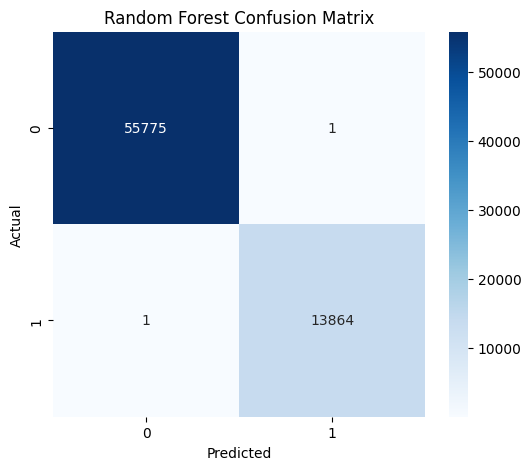

In [24]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

Feature importance

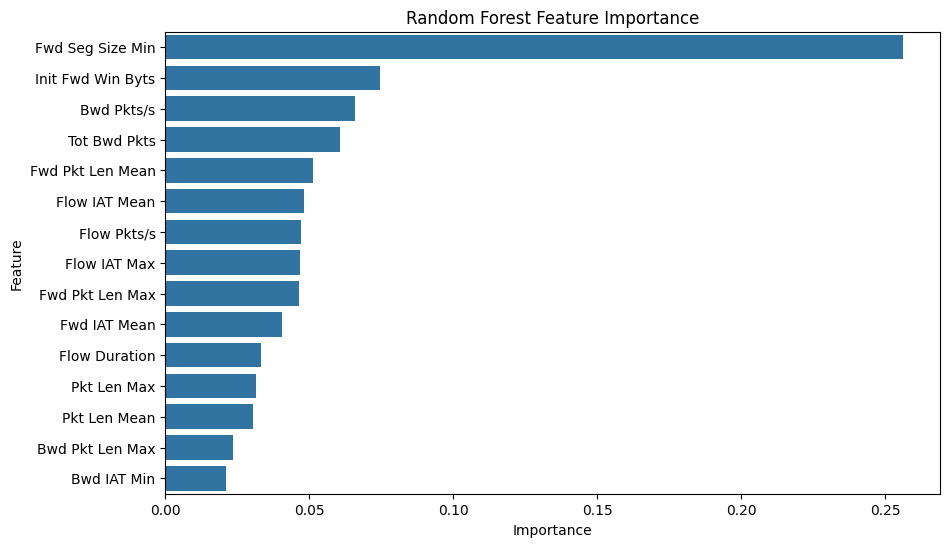

In [25]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})


feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)


feature_importance.head(20)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()

In [26]:
print(feature_importance.head(10))
training_time

              Feature  Importance
0    Fwd Seg Size Min    0.256302
1   Init Fwd Win Byts    0.074501
3          Bwd Pkts/s    0.065904
2        Tot Bwd Pkts    0.060819
9    Fwd Pkt Len Mean    0.051382
5       Flow IAT Mean    0.048192
11        Flow Pkts/s    0.047100
10       Flow IAT Max    0.046944
6     Fwd Pkt Len Max    0.046469
7        Fwd IAT Mean    0.040499


18.566867351531982

Save the model

In [29]:
MODEL_PATH = MODEL_DIR / "random_forest_model.pkl"

joblib.dump(
    rf,
    MODEL_PATH
)

print("Model saved:")
print(MODEL_PATH)

Model saved:
/content/drive/MyDrive/MSc_Dissertation/Results/Models/random_forest_model.pkl


Save the results

In [30]:
results = pd.DataFrame(
    {
        "Model": ["Random Forest"],
        "Dataset": ["Expanded CIC-IDS2018"],
        "Accuracy": [accuracy],
        "Training Time (seconds)": [training_time],
    }
)


RESULT_PATH = MODEL_DIR / "random_forest_results.csv"


results.to_csv(
    RESULT_PATH,
    index=False
)


print("Results saved:")
print(RESULT_PATH)


results

Results saved:
/content/drive/MyDrive/MSc_Dissertation/Results/Models/random_forest_results.csv


,Model,Dataset,Accuracy,Training Time (seconds)
0,Random Forest,Expanded CIC-IDS2018,0.999971,18.566867
